In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Création de nos données

In [391]:
np.random.seed(0)
X, Y = make_regression(n_samples=100, n_features=1, noise=12)
Y = Y.reshape(len(Y), 1)

Y = StandardScaler().fit_transform(Y)
Y = Y**3


X = np.hstack((X**3, X**2, X, np.ones((len(X), 1))))
X = StandardScaler().fit_transform(X)

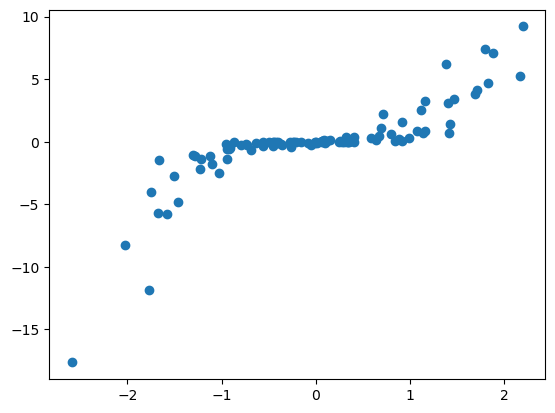

In [393]:
plt.scatter(X[:, 2], Y)

## Régression linéaire from scratch

In [396]:
def fonction_cout(X, Y, theta):
    return np.sum(((X@theta) - Y)**2) / (2*len(X)) 

In [398]:
np.random.seed(0)
theta = np.random.randn(4, 1)
theta.shape

(4, 1)

In [400]:
fonction_cout(X, Y, theta)

1.1402147080518181

### Gradient descent

In [403]:
def gradient_descent(X, Y, theta, alpha, eps):

    cout_new = 0
    cout_old = 1
    theta_old = theta
    theta_new = np.array([])
    while(np.abs(cout_old - cout_new) > eps):
        cout_old = fonction_cout(X, Y, theta_old)
        theta_new = theta_old - alpha * (( (X.T) @ (X @ theta_old - Y)) / len(X))
        cout_new = fonction_cout(X, Y, theta_new)
        theta_old = theta_new
    return theta_new, cout_new

In [405]:
theta_final, cout_new = gradient_descent(X, Y, theta, 0.01, 0.001)
print(theta_final)
print(cout_new)

[[ 2.0346935 ]
 [-0.248673  ]
 [ 0.94402943]
 [ 2.2408932 ]]
0.6969681065275095


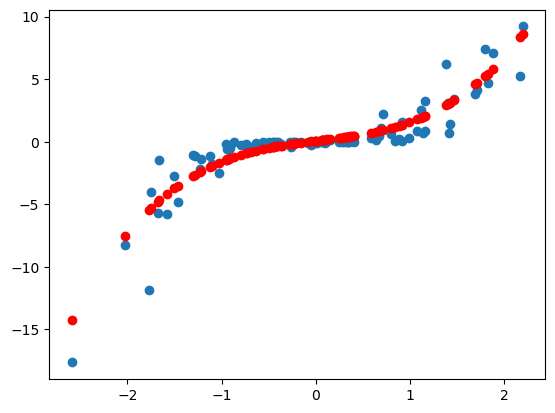

In [407]:
predictions = X@theta_final
plt.figure()
plt.scatter(X[:, 2], Y)
plt.scatter(X[:, 2], predictions, c='r')

In [409]:
predictions.shape

(100, 1)

### Méthode de Newton

In [455]:
# On ajoute un pas "alpha" (learning rate) à la méthode de Newton pour avoir un coût qui ne tend pas vers l'infini
def newton_method(X, Y, theta, bruit, alpha, eps):
    cout_new = 0
    cout_old = 1
    theta_old = theta
    theta_new = np.array([])
    
    # On ajoute du bruit à la matrice Hessienne pour ne pas faire tendre son déterminant vers zéro.
    hessienne = (((X.T) @ X)/len(X)) + bruit*np.eye(len(theta))

    #Si la valeur absolue du déterminant de la Hessienne est proche de 1e-8, on arrête l'algo
    if np.abs(np.linalg.det(hessienne)) < 1e-8:
        print("Déterminant nul")
        return (None, None)
        
    while(np.abs(cout_new - cout_old) > eps):
        cout_old = fonction_cout(X, Y, theta_old)
        
        grad = (X.T) @ ((X @ theta_old) - Y)
        theta_new = theta_old - alpha*(np.linalg.inv(hessienne) @ grad)

        cout_new = fonction_cout(X, Y, theta_new)
        theta_old = theta_new

    return theta_new, cout_new    

In [457]:
theta_final_nwt, cout_new_nwt = newton_method(X, Y, theta, bruit=1, alpha=0.01, eps= 0.01)
print(theta_final_nwt)
print(cout_new_nwt)

[[ 2.35056247]
 [-0.48733932]
 [ 0.68814348]
 [ 2.2408932 ]]
0.6109862056238944


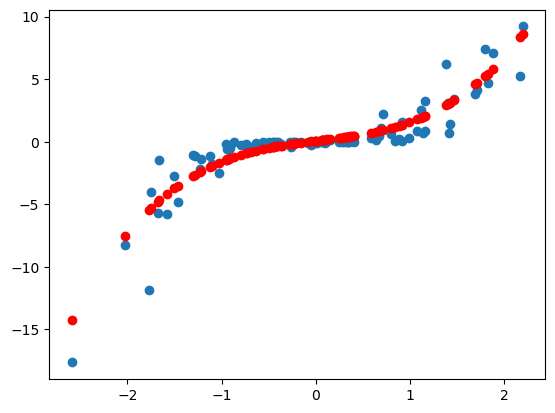

In [459]:
predictions_nwt = X@theta_final_nwt
plt.figure()
plt.scatter(X[:, 2], Y)
plt.scatter(X[:, 2], predictions, c='r')

## Regression Linéaire avec SkLearn

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split

### Création de nouvelles données

In [13]:
np.random.seed(0)
X2, Y2 = make_regression(n_samples=100, n_features=1, noise=12)
Y2 = Y2.reshape(len(Y), 1)
Y2 = Y2**3

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X2, Y2, test_size=0.2, random_state=42, shuffle=True)

In [17]:
pipeline = Pipeline([
    ('std', StandardScaler()),
    ('pol', PolynomialFeatures()),
    ('lrg', LinearRegression())
])

In [131]:
param_grid = [
    {
    'lrg' : [LinearRegression()],
    'pol__degree' : [2, 3, 4, 5],
    'pol__interaction_only' : [False, True]
    },
    {
    'lrg' : [Ridge(), Lasso()],
    'lrg__alpha' : np.arange(0.75, 1, 0.02),
    'pol__degree' : [2, 3, 4, 5],
    'pol__interaction_only' : [False, True]
    },
    {
    'lrg' : [ElasticNet()],
    'lrg__alpha' : np.arange(0.75, 1, 0.02),
    'lrg__l1_ratio' : np.arange(0.15, 0.3, 0.01),
    'pol__degree' : [2, 3, 4, 5],
    'pol__interaction_only' : [False, True]
    }
]

In [133]:
GridSearch = GridSearchCV(
    estimator=pipeline,
    param_grid = param_grid,
    scoring = "r2",
    cv = KFold(n_splits=3),
    n_jobs=5
)

In [135]:
GridSearch.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=3, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('std', StandardScaler()),
                                       ('pol', PolynomialFeatures()),
                                       ('lrg', LinearRegression())]),
             n_jobs=5,
             param_grid=[{'lrg': [LinearRegression()],
                          'pol__degree': [2, 3, 4, 5],
                          'pol__interaction_only': [False, True]},
                         {'lrg': [Ridge(), Lasso()],
                          'lrg__alpha': array([0.75, 0.77, 0.79, 0.81...
       0.97, 0.99]),
                          'pol__degree': [2, 3, 4, 5],
                          'pol__interaction_only': [False, True]},
                         {'lrg': [ElasticNet()],
                          'lrg__alpha': array([0.75, 0.77, 0.79, 0.81, 0.83, 0.85, 0.87, 0.89, 0.91, 0.93, 0.95,
       0.97, 0.99]),
                          'lrg__l1_ratio': array([0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25,
       0.26, 0.27, 0.28, 0.29]),
                          'pol__degree': [2, 3, 4, 5],
                          'pol__interaction_only': [False, True]}],
             scoring='r2')

In [137]:
GridSearch.best_params_

{'lrg': ElasticNet(),
 'lrg__alpha': 0.9100000000000001,
 'lrg__l1_ratio': 0.20000000000000004,
 'pol__degree': 3,
 'pol__interaction_only': False}

In [139]:
model = GridSearch.best_estimator_
model

Pipeline(steps=[('std', StandardScaler()),
                ('pol', PolynomialFeatures(degree=3)),
                ('lrg',
                 ElasticNet(alpha=0.9100000000000001,
                            l1_ratio=0.20000000000000004))])

In [141]:
model.score(X_test, Y_test)

0.84183562127435

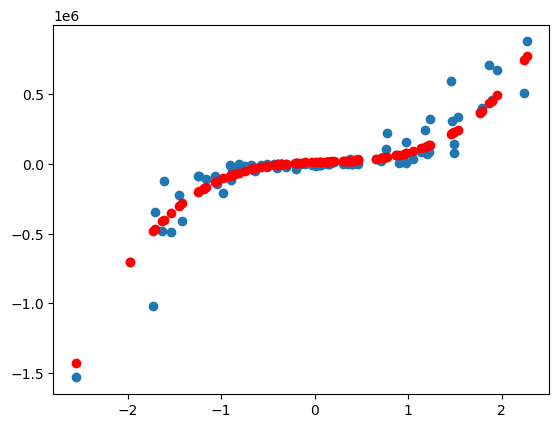

In [143]:
plt.scatter(X2, Y2)
plt.scatter(X2, model.predict(X2), c='r')

### Régression Linéaire classique 
#### (Score plus faible)

In [417]:
lr = LinearRegression()

In [419]:
lr.fit(X_train, Y_train)

LinearRegression()

In [421]:
lr.score(X_test, Y_test)

0.5756111798403825

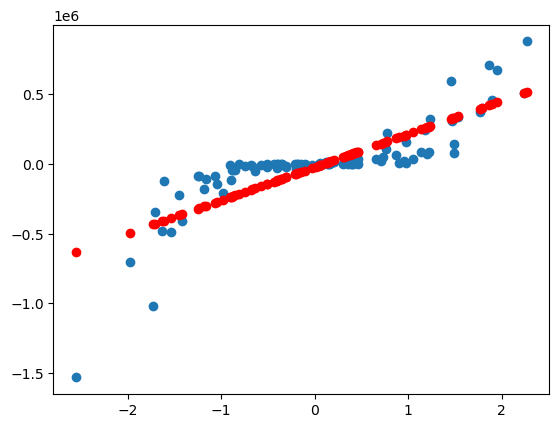

In [425]:
plt.scatter(X2, Y2)
plt.scatter(X2, lr.predict(X2), c='r')